# Capstone Exploratory Data Analysis
**Project:** Predicting Long-Run Home Price Appreciation Across U.S. Housing Markets  
**Notebook:** 03: Exploratory Data Analysis  

This notebook produces the visualizations and descriptive insights that will support the
Task 2 proposal and Task 3 report. All figures are saved to `data/figures/`.

Visualizations produced:
1. Distribution of appreciation rates (histogram)
2. Average appreciation rate by year (line chart: shows 2013 recovery and COVID spike)
3. Top 15 and Bottom 15 appreciating metros: cumulative 2012–2024 (bar chart)
4. Correlation heatmap of all variables
5. Scatter plots: key predictors vs appreciation rate

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

os.makedirs('data/figures', exist_ok=True)

# Consistent style for all figures
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

panel = pd.read_csv('data/processed/panel_dataset.csv')

predictor_cols = [
    'pop_growth_rate', 'unemployment_rate', 'poverty_rate',
    'median_income', 'pct_bachelors_plus', 'vacancy_rate',
    'homeownership_rate', 'mortgage_rate'
]
predictor_labels = {
    'pop_growth_rate':    'Population Growth Rate (%)',
    'unemployment_rate':  'Unemployment Rate (%)',
    'poverty_rate':       'Poverty Rate (%)',
    'median_income':      'Median Household Income ($)',
    'pct_bachelors_plus': "% Bachelor's Degree or Higher",
    'vacancy_rate':       'Vacancy Rate (%)',
    'homeownership_rate': 'Homeownership Rate (%)',
    'mortgage_rate':      '30-Year Fixed Mortgage Rate (%)'
}

print(f'Panel loaded: {len(panel):,} rows | {panel["cbsa"].nunique()} MSAs | {panel["year"].min()}–{panel["year"].max()}')

Panel loaded: 1,178 rows | 99 MSAs | 2012–2024


---
## Figure 1: Distribution of Annual Appreciation Rates

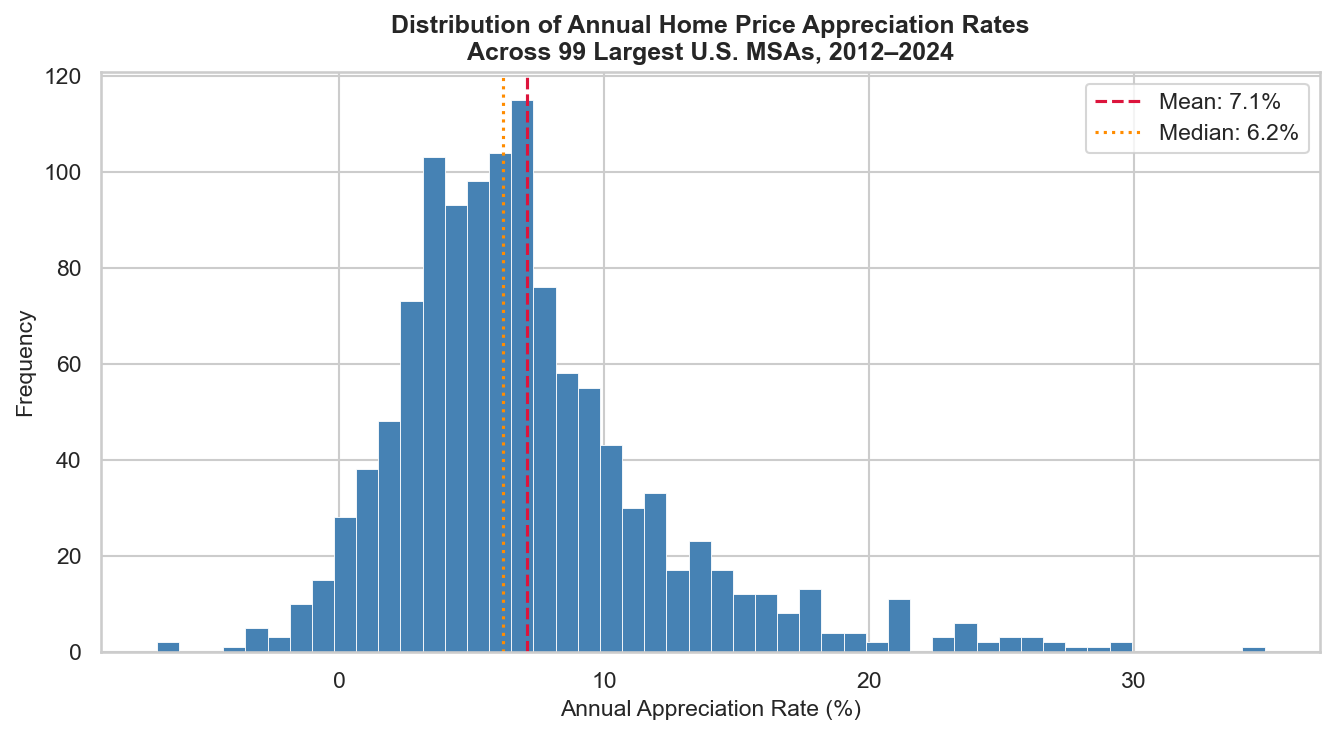

Skewness: 1.343
Min: -6.9%  |  Max: 34.9%


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(panel['appreciation_rate'], bins=50, edgecolor='white', linewidth=0.4, color='steelblue')
ax.axvline(panel['appreciation_rate'].mean(),   color='crimson',  linestyle='--', linewidth=1.5, label=f'Mean: {panel["appreciation_rate"].mean():.1f}%')
ax.axvline(panel['appreciation_rate'].median(), color='darkorange',linestyle=':',  linewidth=1.5, label=f'Median: {panel["appreciation_rate"].median():.1f}%')

ax.set_xlabel('Annual Appreciation Rate (%)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Annual Home Price Appreciation Rates\nAcross 99 Largest U.S. MSAs, 2012–2024', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('data/figures/fig1_appreciation_distribution.png')
plt.show()

print(f'Skewness: {panel["appreciation_rate"].skew():.3f}')
print(f'Min: {panel["appreciation_rate"].min():.1f}%  |  Max: {panel["appreciation_rate"].max():.1f}%')

---
## Figure 2: Average Appreciation Rate by Year (National Trend)

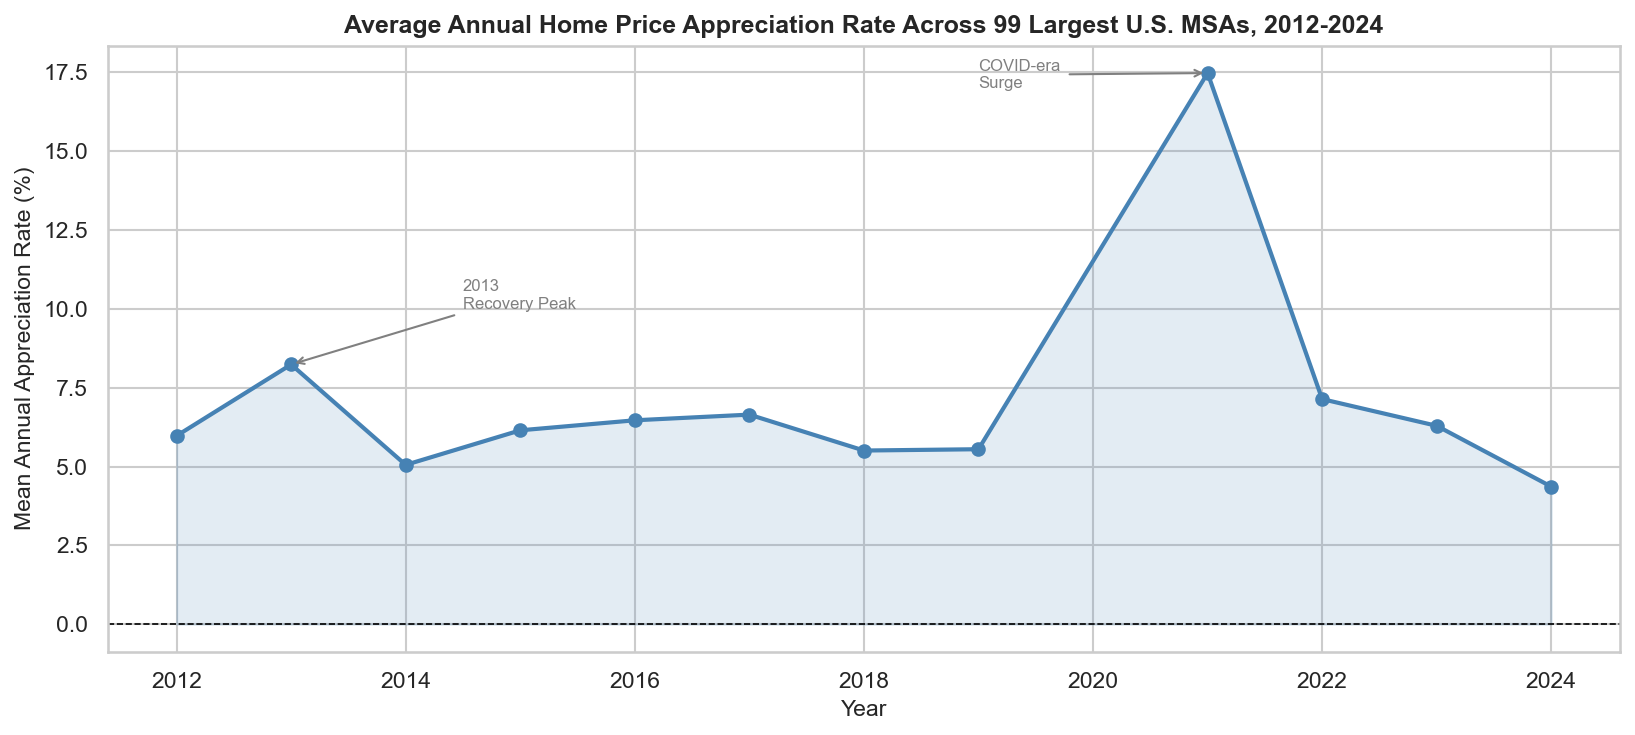

In [13]:
yr_avg = panel.groupby('year')['appreciation_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(yr_avg['year'], yr_avg['appreciation_rate'], marker='o', linewidth=2, color='steelblue')
ax.fill_between(yr_avg['year'], yr_avg['appreciation_rate'], alpha=0.15, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Annotate key events
ax.annotate('2013\nRecovery Peak', 
            xy=(2013, yr_avg.loc[yr_avg['year']==2013,'appreciation_rate'].values[0]),
            xytext=(2014.5, 10), 
            arrowprops=dict(arrowstyle='->', color='gray'), 
            fontsize=8, color='gray')

ax.annotate('COVID-era\nSurge', 
            xy=(2021, yr_avg.loc[yr_avg['year']==2021,'appreciation_rate'].values[0]),
            xytext=(2019, 17), 
            arrowprops=dict(arrowstyle='->', color='gray'), 
            fontsize=8, color='gray')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean Annual Appreciation Rate (%)', fontsize=11)
ax.set_title('Average Annual Home Price Appreciation Rate Across 99 Largest U.S. MSAs, 2012-2024', fontsize=12, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.tight_layout()
plt.savefig('data/figures/fig2_appreciation_by_year.png')
plt.show()

---
## Figure 3: Top 15 and Bottom 15 Metropolitan Areas: Cumulative Appreciation

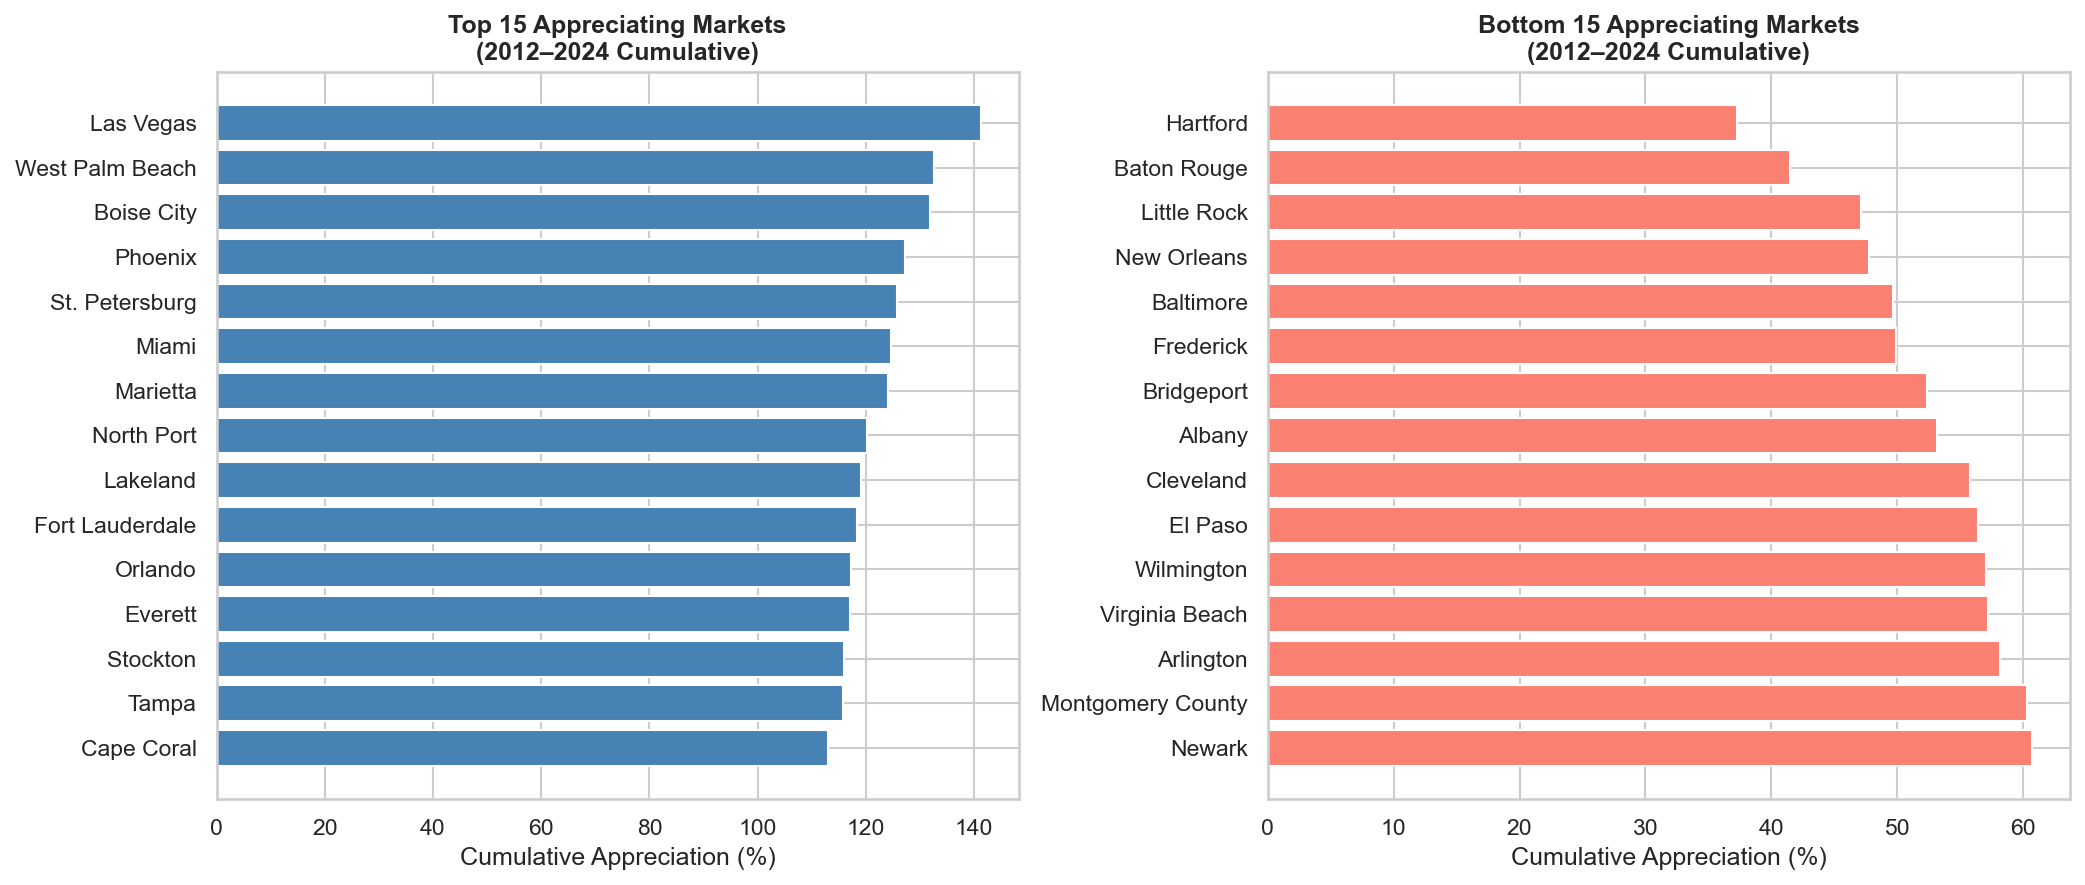

Top 5 cumulative:
                                        metro_name  cumulative_appreciation
           Las Vegas-Henderson-North Las Vegas, NV               141.204140
West Palm Beach-Boca Raton-Delray Beach, FL (MSAD)               132.676800
                                    Boise City, ID               131.920273
                         Phoenix-Mesa-Chandler, AZ               127.248318
        St. Petersburg-Clearwater-Largo, FL (MSAD)               125.673532

Bottom 5 cumulative:
                              metro_name  cumulative_appreciation
           Baltimore-Columbia-Towson, MD                49.645706
                New Orleans-Metairie, LA                47.729631
Little Rock-North Little Rock-Conway, AR                47.129730
                         Baton Rouge, LA                41.500987
Hartford-West Hartford-East Hartford, CT                37.245325


In [14]:
# Cumulative appreciation: sum of annual rates per metro across full study period
cum_appr = (
    panel.groupby('metro_name')['appreciation_rate']
    .sum()
    .reset_index()
    .rename(columns={'appreciation_rate': 'cumulative_appreciation'})
    .sort_values('cumulative_appreciation', ascending=False)
)

top15 = cum_appr.head(15)
bot15 = cum_appr.tail(15).sort_values('cumulative_appreciation')

# Shorten metro names for readability
def shorten(name):
    return name.split('-')[0].split(',')[0].strip()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(top15['metro_name'].apply(shorten), top15['cumulative_appreciation'], color='steelblue')
ax1.set_xlabel('Cumulative Appreciation (%)')
ax1.set_title('Top 15 Appreciating Markets\n(2012–2024 Cumulative)', fontweight='bold')
ax1.invert_yaxis()

ax2.barh(bot15['metro_name'].apply(shorten), bot15['cumulative_appreciation'], color='salmon')
ax2.set_xlabel('Cumulative Appreciation (%)')
ax2.set_title('Bottom 15 Appreciating Markets\n(2012–2024 Cumulative)', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('data/figures/fig3_top_bottom_metros.png')
plt.show()

print('Top 5 cumulative:')
print(cum_appr.head(5)[['metro_name','cumulative_appreciation']].to_string(index=False))
print('\nBottom 5 cumulative:')
print(cum_appr.tail(5)[['metro_name','cumulative_appreciation']].to_string(index=False))

---
## Figure 4: Correlation Heatmap

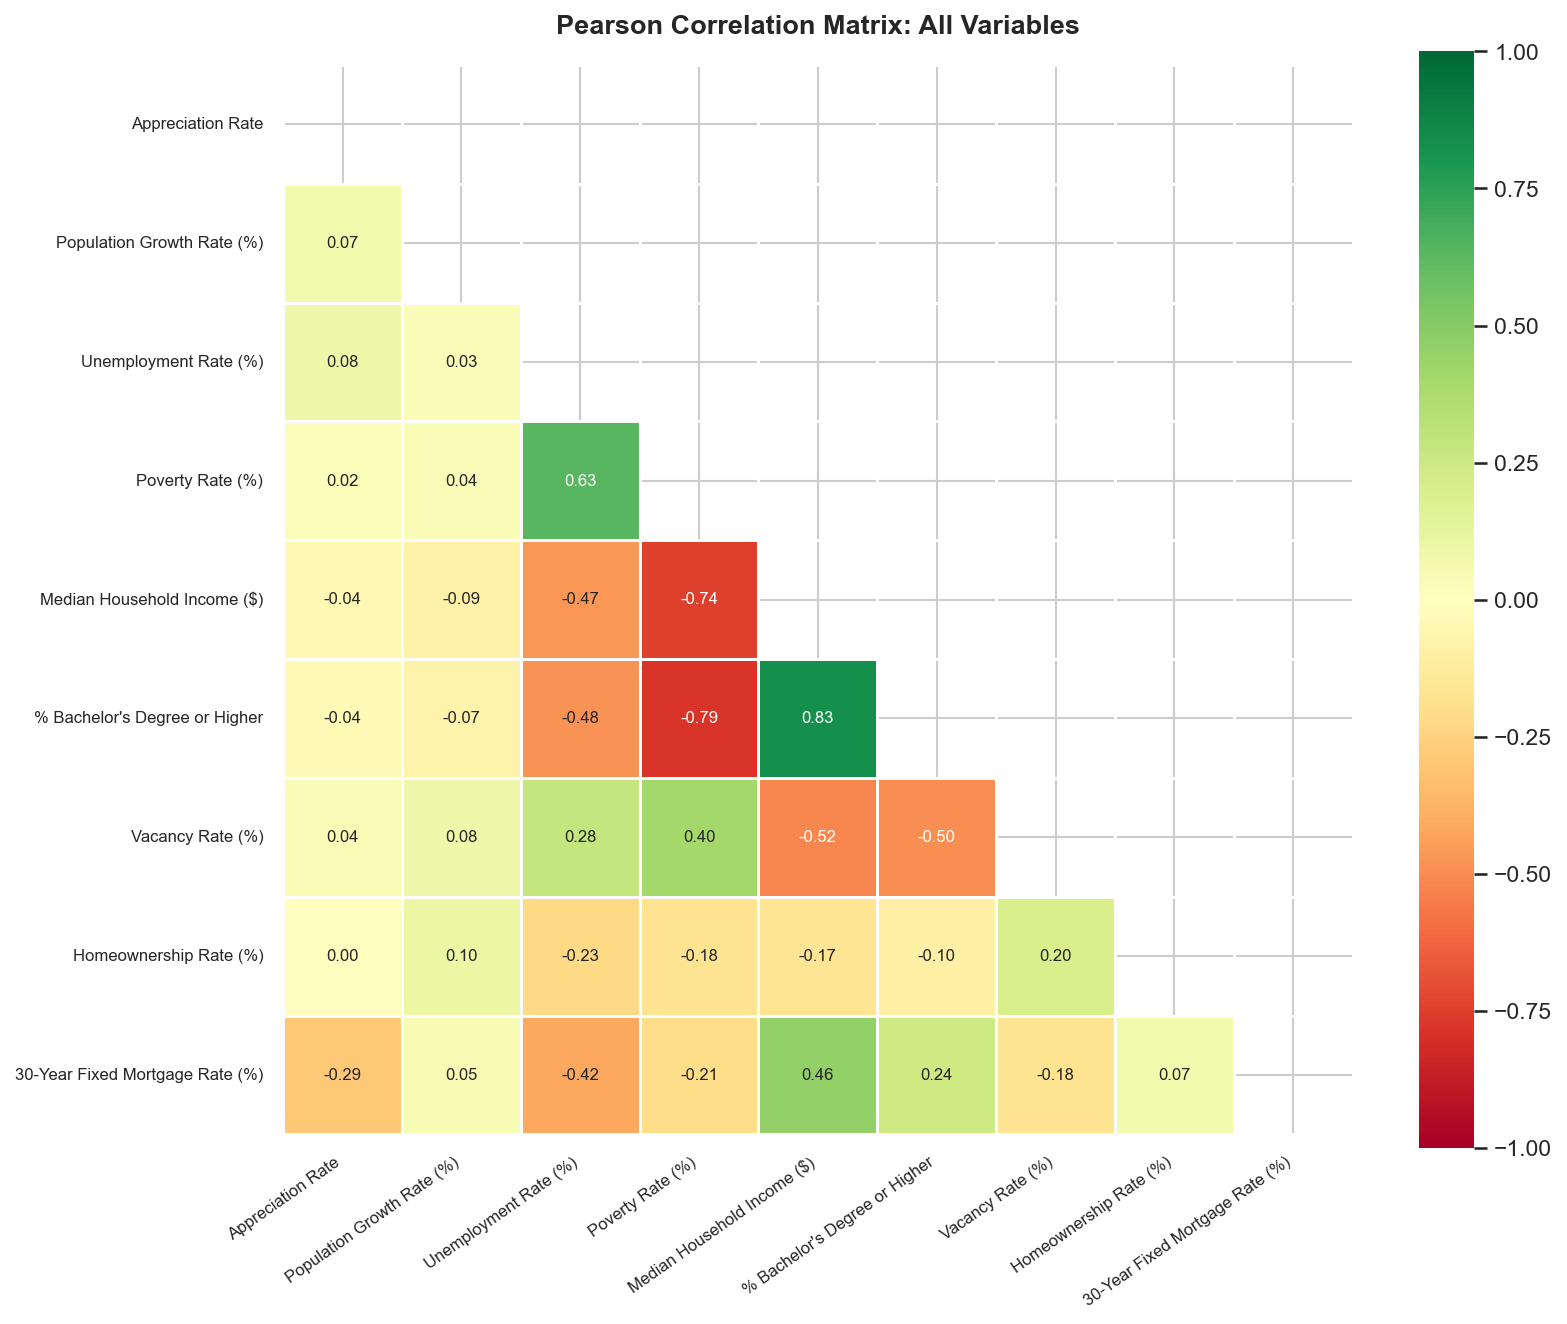

Correlations with appreciation_rate (sorted):
Unemployment Rate (%)              0.084
Population Growth Rate (%)         0.066
Vacancy Rate (%)                   0.035
Poverty Rate (%)                   0.023
Homeownership Rate (%)             0.004
% Bachelor's Degree or Higher     -0.036
Median Household Income ($)       -0.041
30-Year Fixed Mortgage Rate (%)   -0.290


In [15]:
corr_cols = ['appreciation_rate'] + predictor_cols
corr_labels = {'appreciation_rate': 'Appreciation Rate'}
corr_labels.update(predictor_labels)

corr_df = panel[corr_cols].rename(columns=corr_labels)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix: All Variables', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('data/figures/fig4_correlation_heatmap.png')
plt.show()

print('Correlations with appreciation_rate (sorted):')
print(corr_matrix['Appreciation Rate'].drop('Appreciation Rate').sort_values(ascending=False).round(3).to_string())

---
## Figure 5: Scatter Plots: Top 4 Predictors vs Appreciation Rate

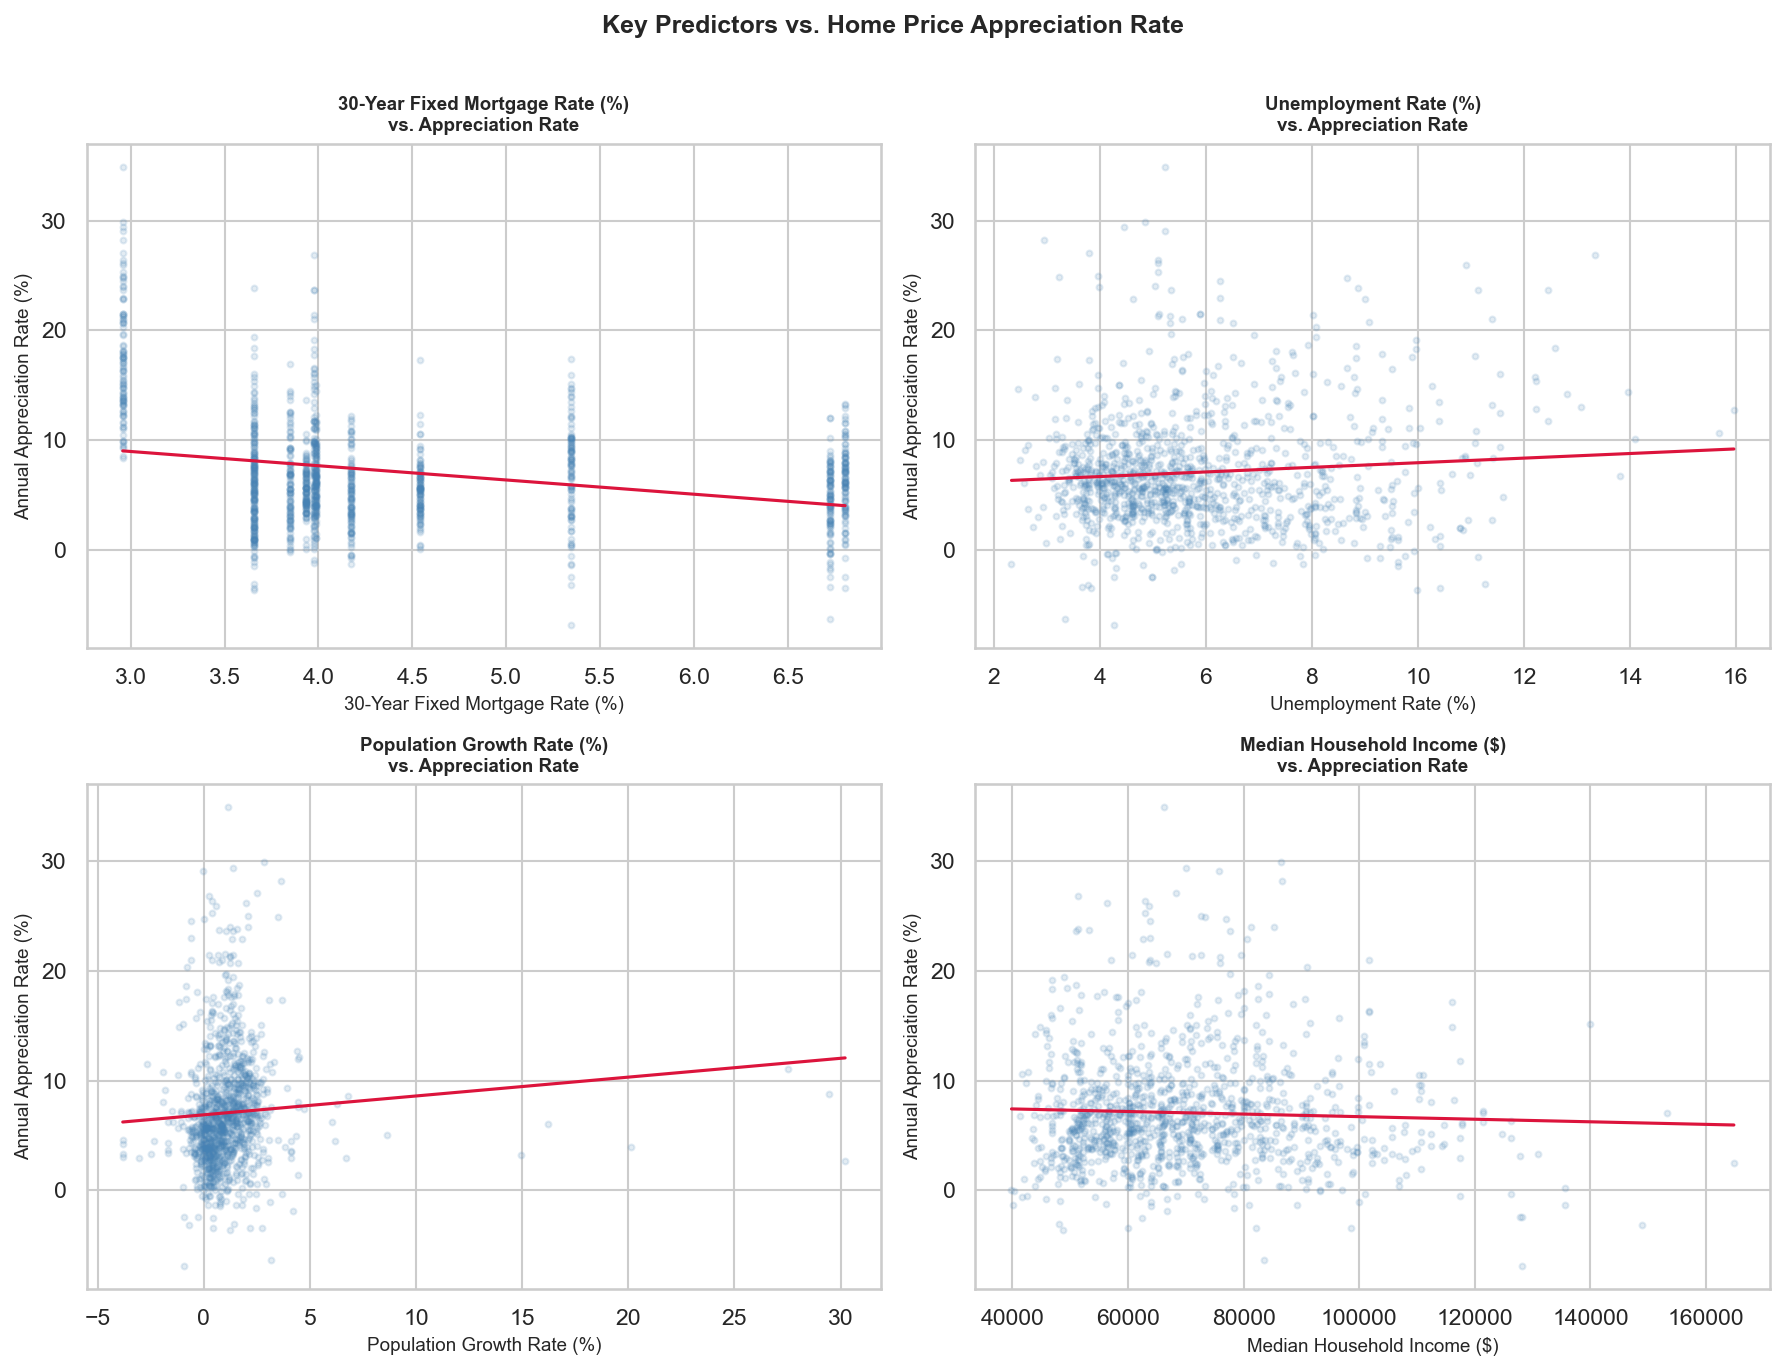

In [16]:
# Top 4 predictors by absolute Pearson correlation with appreciation_rate
top_predictors = ['mortgage_rate', 'unemployment_rate', 'pop_growth_rate', 'median_income']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(top_predictors):
    axes[i].scatter(
        panel[col], panel['appreciation_rate'],
        alpha=0.15, s=8, color='steelblue'
    )
    # Trend line
    m, b = np.polyfit(panel[col].dropna(), panel.loc[panel[col].notna(), 'appreciation_rate'], 1)
    x_range = np.linspace(panel[col].min(), panel[col].max(), 100)
    axes[i].plot(x_range, m * x_range + b, color='crimson', linewidth=1.5)

    axes[i].set_xlabel(predictor_labels[col], fontsize=9)
    axes[i].set_ylabel('Annual Appreciation Rate (%)', fontsize=9)
    axes[i].set_title(f'{predictor_labels[col]}\nvs. Appreciation Rate', fontsize=9, fontweight='bold')

plt.suptitle('Key Predictors vs. Home Price Appreciation Rate', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/figures/fig5_scatter_predictors.png', bbox_inches='tight')
plt.show()

---
## Summary Output for Task 2 Writing

In [17]:
print('=' * 45)
print('EDA SUMMARY')
print('=' * 45)
print(f'Total panel observations:     {len(panel):,}')
print(f'Unique MSAs:                  {panel["cbsa"].nunique()}')
print(f'Year range:                   {panel["year"].min()} – {panel["year"].max()}')
print()
print('Appreciation rate:')
print(f'  Mean:   {panel["appreciation_rate"].mean():.2f}%')
print(f'  Median: {panel["appreciation_rate"].median():.2f}%')
print(f'  Std:    {panel["appreciation_rate"].std():.2f}%')
print(f'  Min:    {panel["appreciation_rate"].min():.2f}%')
print(f'  Max:    {panel["appreciation_rate"].max():.2f}%')
print()
print('Figures saved to data/figures/')
figs = [f for f in os.listdir('data/figures') if f.endswith('.png')]
for f in sorted(figs):
    print(f'  {f}')

EDA SUMMARY
Total panel observations:     1,178
Unique MSAs:                  99
Year range:                   2012 – 2024

Appreciation rate:
  Mean:   7.08%
  Median: 6.17%
  Std:    5.17%
  Min:    -6.88%
  Max:    34.92%

Figures saved to data/figures/
  fig1_appreciation_distribution.png
  fig2_appreciation_by_year.png
  fig3_top_bottom_metros.png
  fig4_correlation_heatmap.png
  fig5_scatter_predictors.png
